In [1]:
# Cell 0 — Clone repo (Colab only)
import os, subprocess
if 'google.colab' in str(get_ipython()):
    REPO_DIR = '/content/trading-strategies'
    if not os.path.exists(os.path.join(REPO_DIR, 'lib', 'data_manager.py')):
        if os.path.exists(REPO_DIR):
            import shutil; shutil.rmtree(REPO_DIR)
        result = subprocess.run(['git', 'clone', 'https://github.com/r-giov/trading-strategies.git', REPO_DIR], capture_output=True, text=True)
        if result.returncode != 0:
            try:
                from google.colab import userdata; token = userdata.get('GITHUB_TOKEN')
            except:
                token = None
            if not token:
                raise RuntimeError("Git clone failed. Add GITHUB_TOKEN as Colab secret.")
            subprocess.run(['git', 'clone', f'https://{token}@github.com/r-giov/trading-strategies.git', REPO_DIR], capture_output=True, text=True)
    assert os.path.isfile(os.path.join(REPO_DIR, 'lib', 'data_manager.py')), "Clone failed"
    os.chdir(REPO_DIR)
    print(f"Repo ready at {REPO_DIR}")
else:
    print("Not in Colab")

Not in Colab


In [2]:
# Cell 1 — Pip installs (uncomment if needed)
# !pip install yfinance
# !pip install TA-Lib
# !pip install numpy
# !pip install pandas
# !pip install vectorbt
# !pip install scipy
# !pip install matplotlib

In [3]:
# Cell 2 — Imports + path setup
import sys, os

_repo = '/content/trading-strategies'
if os.path.isdir(os.path.join(_repo, 'lib')):
    if _repo not in sys.path:
        sys.path.insert(0, _repo)
else:
    _parent = os.path.join(os.getcwd(), '..')
    if os.path.isdir(os.path.join(_parent, 'lib')) and _parent not in sys.path:
        sys.path.insert(0, os.path.abspath(_parent))

import yfinance as yf
import talib
import numpy as np
import pandas as pd
import vectorbt as vbt
import warnings
from scipy import stats
import matplotlib.pyplot as plt
from itertools import product

warnings.filterwarnings('ignore')
pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 140)

print(f"\nPackages: vectorbt={vbt.__version__}, pandas={pd.__version__}, numpy={np.__version__}")
print("All imports loaded")


Packages: vectorbt=0.28.1, pandas=2.3.2, numpy=2.3.3
All imports loaded


In [4]:
# ═══════════════════════════════════════════════════════════════
# Cell 3 — Download 1H data (max 730 days from yfinance)
# ═══════════════════════════════════════════════════════════════

TICKERS = ['GC=F', 'CL=F', 'SI=F', 'QQQ', 'SPY', 'BTC-USD']
PRIMARY_TICKER = 'GC=F'

print(f"Downloading 1H data for {len(TICKERS)} tickers (max 730 days)...\n")

all_data = {}
for ticker in TICKERS:
    df = yf.download(ticker, period='730d', interval='1h', progress=False)
    if df is not None and not df.empty:
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [c[0] for c in df.columns]
        df = df.dropna()
        all_data[ticker] = df
        print(f"  {ticker}: {len(df)} bars ({df.index[0]} to {df.index[-1]})")

stock_data = all_data[PRIMARY_TICKER]
TICKER = PRIMARY_TICKER
print(f"\nPrimary: {TICKER} — {len(stock_data)} 1H bars")
stock_data.tail(5)

  GC=F: 13693 bars (2023-10-15 22:00:00+00:00 to 2026-03-08 23:00:00+00:00)


  CL=F: 13436 bars (2023-10-15 22:00:00+00:00 to 2026-03-08 23:00:00+00:00)


  SI=F: 13690 bars (2023-10-15 22:00:00+00:00 to 2026-03-08 23:00:00+00:00)


  QQQ: 5069 bars (2023-04-10 13:30:00+00:00 to 2026-03-06 20:30:00+00:00)


  SPY: 5068 bars (2023-04-10 13:30:00+00:00 to 2026-03-06 20:30:00+00:00)


  BTC-USD: 17461 bars (2024-03-10 00:00:00+00:00 to 2026-03-09 00:00:00+00:00)

Primary: GC=F — 13693 1H bars


,Close,High,Low,Open,Volume
Datetime,,,,,
2026-03-06 19:00:00+00:00,5168.500000,5183.799805,5165.200195,5170.399902,3745
2026-03-06 20:00:00+00:00,5161.399902,5171.200195,5157.500000,5168.200195,4144
2026-03-06 21:00:00+00:00,5158.700195,5185.000000,5158.700195,5161.100098,2451
2026-03-08 22:00:00+00:00,5138.500000,5180.000000,5113.500000,5165.500000,5619
2026-03-08 23:00:00+00:00,5081.500000,5145.500000,5050.000000,5140.299805,10060


In [5]:
# ═══════════════════════════════════════════════════════════════
# Cell 4 — Indicators: MOM, SMA, ATR, ADX on 1H data
# ═══════════════════════════════════════════════════════════════

close = stock_data['Close'].values.astype(float)
high = stock_data['High'].values.astype(float)
low = stock_data['Low'].values.astype(float)
idx = stock_data.index

indicators_df = pd.DataFrame({
    'Close': close,
    'MOM_5': talib.MOM(close, timeperiod=5),
    'MOM_10': talib.MOM(close, timeperiod=10),
    'MOM_14': talib.MOM(close, timeperiod=14),
    'MOM_21': talib.MOM(close, timeperiod=21),
    'SMA_20': talib.SMA(close, timeperiod=20),
    'SMA_50': talib.SMA(close, timeperiod=50),
    'SMA_100': talib.SMA(close, timeperiod=100),
    'SMA_200': talib.SMA(close, timeperiod=200),
    'ATR_14': talib.ATR(high, low, close, timeperiod=14),
    'ADX_14': talib.ADX(high, low, close, timeperiod=14),
}, index=idx)

print(f"Indicators computed for {TICKER} (1H bars)")
print(f"\nMomentum(10) zero-crossings: {((indicators_df['MOM_10'].shift(1) <= 0) & (indicators_df['MOM_10'] > 0)).sum()} bullish")
print(f"Momentum(5) zero-crossings:  {((indicators_df['MOM_5'].shift(1) <= 0) & (indicators_df['MOM_5'] > 0)).sum()} bullish")
print(f"Average ATR(14): ${indicators_df['ATR_14'].mean():.2f}")
print(f"Average ADX(14): {indicators_df['ADX_14'].mean():.1f}")
print(f"\nTotal 1H bars: {len(indicators_df)}")
indicators_df.tail(10)

Indicators computed for GC=F (1H bars)

Momentum(10) zero-crossings: 995 bullish
Momentum(5) zero-crossings:  1444 bullish
Average ATR(14): $11.59
Average ADX(14): 28.5

Total 1H bars: 13693


,Close,MOM_5,MOM_10,MOM_14,MOM_21,SMA_20,SMA_50,SMA_100,SMA_200,ATR_14,ADX_14
Datetime,,,,,,,,,,,
2026-03-06 14:00:00+00:00,5139.299805,45.799805,2.099609,46.799805,52.799805,5108.710010,5139.176025,5200.120000,5208.155996,31.563603,23.867879
2026-03-06 15:00:00+00:00,5151.200195,51.300293,24.600098,9.100098,80.000000,5112.390015,5138.116025,5197.402002,5207.639497,32.494781,23.368678
2026-03-06 16:00:00+00:00,5149.500000,63.399902,24.600098,15.600098,71.899902,5116.135010,5137.466025,5194.808003,5207.171497,32.102297,22.839106
2026-03-06 17:00:00+00:00,5150.200195,58.300293,22.000000,10.300293,75.600098,5119.315015,5136.900029,5192.241006,5206.939497,31.530676,22.347361
2026-03-06 18:00:00+00:00,5170.299805,76.500000,53.599609,33.099609,83.699707,5123.165015,5137.192021,5189.903003,5206.745996,31.321349,22.385247
2026-03-06 19:00:00+00:00,5168.500000,29.200195,75.000000,41.899902,75.200195,5126.810010,5137.330020,5187.592002,5206.628496,30.412653,22.669055
2026-03-06 20:00:00+00:00,5161.399902,10.199707,61.500000,36.500000,65.799805,5130.255005,5137.328018,5185.082002,5206.493496,29.218906,22.492405
2026-03-06 21:00:00+00:00,5158.700195,9.200195,72.600098,30.500000,66.200195,5131.085010,5137.430020,5182.571006,5206.271997,29.010399,22.818766
2026-03-08 22:00:00+00:00,5138.500000,-11.700195,46.600098,21.799805,-3.600098,5131.315015,5137.306016,5180.492007,5205.996497,31.688228,21.368835


In [6]:
# ═══════════════════════════════════════════════════════════════
# Cell 5 — IS/OOS Split + FTMO Config
# ═══════════════════════════════════════════════════════════════

TRAIN_RATIO = 0.60
INIT_CASH   = 100_000
FEES        = 0.0005
SLIPPAGE    = 0.0005
FTMO_LEVERAGE = 5.0   # Conservative leverage (FTMO allows up to 1:100 on commodities)
RISK_PER_TRADE = 0.01  # 1% risk per trade

close_series = stock_data['Close'].astype(float)
close_series.name = 'price'
high_series = stock_data['High'].astype(float)
low_series = stock_data['Low'].astype(float)

split_idx = int(len(close_series) * TRAIN_RATIO)
train_close = close_series.iloc[:split_idx]
val_close   = close_series.iloc[split_idx:]

print(f"Total 1H bars: {len(close_series)}")
print(f"Train/Val split at index {split_idx} ({TRAIN_RATIO:.0%}/{1-TRAIN_RATIO:.0%})")
print(f"  Train: {len(train_close)} bars | {train_close.index[0]} -> {train_close.index[-1]}")
print(f"  Val:   {len(val_close)} bars  | {val_close.index[0]} -> {val_close.index[-1]}")
print(f"\nFTMO Settings:")
print(f"  Leverage: {FTMO_LEVERAGE}x")
print(f"  Risk/trade: {RISK_PER_TRADE:.0%}")
print(f"  Init cash: ${INIT_CASH:,}")
print(f"  Fees: {FEES:.2%} | Slippage: {SLIPPAGE:.2%}")

Total 1H bars: 13693
Train/Val split at index 8215 (60%/40%)
  Train: 8215 bars | 2023-10-15 22:00:00+00:00 -> 2025-03-21 16:00:00+00:00
  Val:   5478 bars  | 2025-03-21 17:00:00+00:00 -> 2026-03-08 23:00:00+00:00

FTMO Settings:
  Leverage: 5.0x
  Risk/trade: 1%
  Init cash: $100,000
  Fees: 0.05% | Slippage: 0.05%


## Momentum Breakout FTMO 1H — Strategy Description

**Adapted from:** Momentum_Breakout_Strategy (daily) for FTMO prop firm challenge on 1H bars.

**Why 1H?** Daily bars produce ~20-40 trades/year — not enough for a 30-day FTMO challenge. Moving to 1H generates significantly more signals while preserving the same momentum breakout logic.

**Concept:** Momentum measures the rate of price change. When momentum crosses from negative to positive, the asset is accelerating upward. Combined with a trend filter (price > SMA) and optional ADX filter (trending market), this captures the start of new uptrends.

**Entry (Long only):**
- Momentum(period) crosses above 0 (acceleration turns positive)
- Price must be above SMA trend filter (confirms uptrend)
- Optional: ADX must be above threshold (confirms trending, not ranging)
- **1-bar execution delay** applied to all signals

**Exit:**
- Momentum crosses below 0 (acceleration turns negative)
- OR Stop Loss hit (ATR-based, as fraction of price)
- OR Take Profit hit (ATR-based, as fraction of price)

**FTMO Adaptations:**
- 1H timeframe with `freq='h'` for all annualized metrics
- Default position sizing (no `size_type`); leverage applied as a multiplier on daily returns in Monte Carlo simulation
- FTMO Monte Carlo: 10,000 paths x 30 trading days using OOS hourly returns grouped into daily returns, scaled by `FTMO_LEVERAGE`
- Tracks daily DD, total DD, and profit target for realistic FTMO challenge simulation

**Parameters to Optimize (1H-optimized ranges):**

| Parameter | Description | Range |
|---|---|---|
| `mom_period` | Momentum lookback (1H bars) | 3, 5, 8, 10, 14 |
| `trend_period` | SMA trend filter | 20, 50, 100, 200 |
| `adx_threshold` | Min ADX for entry (0=off) | 0, 15, 20, 25 |
| `sl_atr_mult` | Stop loss ATR multiplier | 1.0, 1.5, 2.0 |
| `tp_atr_mult` | Take profit ATR multiplier | 2.0, 3.0, 4.0 |

**Total combinations:** 5 x 4 x 4 x 3 x 3 = 720

In [7]:
# ═══════════════════════════════════════════════════════════════
# Cell 7 — Signal Engine + Parameter Grid
# ═══════════════════════════════════════════════════════════════

def generate_momentum_signals(close_s, high_s, low_s, mom_period=10,
                               trend_period=50, adx_threshold=0):
    """
    Momentum Breakout with trend + ADX filter.
    Entry: MOM crosses above 0, price > SMA, optional ADX > threshold
    Exit: MOM crosses below 0
    All signals shifted 1 bar for execution delay.
    """
    c = close_s.values.astype(float)
    h = high_s.values.astype(float)
    l = low_s.values.astype(float)
    idx = close_s.index

    mom = pd.Series(talib.MOM(c, timeperiod=mom_period), index=idx)
    trend = pd.Series(talib.SMA(c, timeperiod=trend_period), index=idx)
    price = pd.Series(c, index=idx)

    e_raw = (mom.shift(1) <= 0) & (mom > 0) & (price > trend)

    if adx_threshold > 0:
        adx = pd.Series(talib.ADX(h, l, c, timeperiod=14), index=idx)
        e_raw = e_raw & (adx > adx_threshold)

    x_raw = (mom.shift(1) >= 0) & (mom < 0)

    # 1-bar execution delay
    entries = e_raw.shift(1).fillna(False).astype(bool)
    exits = x_raw.shift(1).fillna(False).astype(bool)
    return entries, exits


def compute_atr_stops(close_s, high_s, low_s, sl_mult=None, tp_mult=None, atr_period=14):
    """Compute ATR-based stops as fraction of price."""
    c = close_s.values.astype(float)
    h = high_s.values.astype(float)
    l = low_s.values.astype(float)
    atr = pd.Series(talib.ATR(h, l, c, timeperiod=atr_period), index=close_s.index)
    sl_stop = (atr * sl_mult / close_s).fillna(0.02) if sl_mult else None
    tp_stop = (atr * tp_mult / close_s).fillna(0.04) if tp_mult else None
    return sl_stop, tp_stop


# Parameter ranges — tighter, optimized for 1H bars
mom_range   = [3, 5, 8, 10, 14]
trend_range = [20, 50, 100, 200]
adx_range   = [0, 15, 20, 25]
sl_range    = [1.0, 1.5, 2.0]
tp_range    = [2.0, 3.0, 4.0]

all_combos = list(product(mom_range, trend_range, adx_range, sl_range, tp_range))
total_combos = len(all_combos)

print(f"Signal engine defined")
print(f"\nParameter Ranges (1H-optimized):")
print(f"  mom_period:     {mom_range}")
print(f"  trend_period:   {trend_range}")
print(f"  adx_threshold:  {adx_range}")
print(f"  sl_atr_mult:    {sl_range}")
print(f"  tp_atr_mult:    {tp_range}")
print(f"\nTotal combinations: {total_combos:,}")

# Sanity check
e_test, x_test = generate_momentum_signals(close_series, high_series, low_series)
print(f"\nSanity check ({TICKER}, defaults): Entries={e_test.sum()}, Exits={x_test.sum()}")

Signal engine defined

Parameter Ranges (1H-optimized):
  mom_period:     [3, 5, 8, 10, 14]
  trend_period:   [20, 50, 100, 200]
  adx_threshold:  [0, 15, 20, 25]
  sl_atr_mult:    [1.0, 1.5, 2.0]
  tp_atr_mult:    [2.0, 3.0, 4.0]

Total combinations: 720

Sanity check (GC=F, defaults): Entries=603, Exits=994


In [8]:
# ═══════════════════════════════════════════════════════════════
# Cell 8 — Initialize Results Collection
# ═══════════════════════════════════════════════════════════════

grid_results = []

METRIC_COLS = [
    'mom_period', 'trend_period', 'adx_threshold', 'sl_atr_mult', 'tp_atr_mult',
    'sharpe_ratio', 'sortino_ratio', 'total_return', 'ann_return',
    'max_drawdown', 'volatility', 'calmar_ratio',
    'total_trades', 'trades_per_year', 'win_rate',
    'profit_factor', 'expectancy', 'avg_win', 'avg_loss',
    'largest_win', 'largest_loss', 'payoff_ratio',
]

print(f"Results collection initialized — tracking {len(METRIC_COLS)} metrics per combo")

Results collection initialized — tracking 22 metrics per combo


In [9]:
# ═══════════════════════════════════════════════════════════════
# Cell 9 — Grid Search on IS data (1H, freq='h')
# ═══════════════════════════════════════════════════════════════

print(f"Running grid search on {TICKER} 1H training data ({total_combos:,} combos)...\n")

train_high = high_series.iloc[:split_idx]
train_low  = low_series.iloc[:split_idx]

# Estimate hours per year for 1H bars (~252 trading days * ~7 trading hours)
HOURS_PER_YEAR = 252 * 7

for combo_idx, (mom_p, trend_p, adx_t, sl_m, tp_m) in enumerate(all_combos):
    if (combo_idx + 1) % 200 == 0:
        print(f"  Combo {combo_idx+1:,}/{total_combos:,}... ({len(grid_results)} valid)")

    try:
        ent, ext = generate_momentum_signals(train_close, train_high, train_low,
                                              mom_period=mom_p, trend_period=trend_p,
                                              adx_threshold=adx_t)
        if ent.sum() < 10:
            continue

        sl_stop, tp_stop = compute_atr_stops(train_close, train_high, train_low,
                                              sl_mult=sl_m, tp_mult=tp_m)
        kw = dict(init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='h')
        if sl_stop is not None: kw['sl_stop'] = sl_stop
        if tp_stop is not None: kw['tp_stop'] = tp_stop

        pf = vbt.Portfolio.from_signals(close=train_close, entries=ent, exits=ext, **kw)
        trades_obj = pf.trades
        n_trades = trades_obj.count()
        if n_trades < 10:
            continue

        tr = np.asarray(trades_obj.returns.values if hasattr(trades_obj.returns, 'values') else trades_obj.returns).ravel()
        pos = tr[tr > 0]; neg = tr[tr < 0]
        years = max(len(train_close) / HOURS_PER_YEAR, 0.01)

        def safe(fn, default=np.nan):
            try: return float(fn())
            except: return default

        row = {
            'mom_period': mom_p, 'trend_period': trend_p, 'adx_threshold': adx_t,
            'sl_atr_mult': sl_m, 'tp_atr_mult': tp_m,
            'sharpe_ratio': safe(lambda: pf.sharpe_ratio(freq='h')),
            'sortino_ratio': safe(lambda: pf.sortino_ratio(freq='h')),
            'total_return': safe(pf.total_return),
            'ann_return': safe(lambda: pf.annualized_return(freq='h')),
            'max_drawdown': safe(pf.max_drawdown),
            'volatility': safe(lambda: pf.annualized_volatility(freq='h')),
            'calmar_ratio': np.nan,
            'total_trades': int(n_trades),
            'trades_per_year': n_trades / years,
            'win_rate': float(len(pos)/len(tr)*100) if len(tr) > 0 else np.nan,
            'profit_factor': float(pos.sum()/abs(neg.sum())) if len(neg) > 0 and abs(neg.sum()) > 0 else np.nan,
            'expectancy': float(tr.mean()) if len(tr) > 0 else np.nan,
            'avg_win': float(pos.mean()) if len(pos) > 0 else np.nan,
            'avg_loss': float(neg.mean()) if len(neg) > 0 else np.nan,
            'largest_win': float(pos.max()) if len(pos) > 0 else np.nan,
            'largest_loss': float(neg.min()) if len(neg) > 0 else np.nan,
            'payoff_ratio': float(abs(pos.mean()/neg.mean())) if len(pos) > 0 and len(neg) > 0 else np.nan,
        }

        ann_r, max_dd = row['ann_return'], row['max_drawdown']
        if not np.isnan(ann_r) and not np.isnan(max_dd) and abs(max_dd) > 1e-9:
            row['calmar_ratio'] = ann_r / abs(max_dd)
        grid_results.append(row)
    except:
        pass

if not grid_results:
    print("WARNING: No valid combos found. Check signal generation and data.")
    results_df = pd.DataFrame(columns=METRIC_COLS)
else:
    results_df = pd.DataFrame(grid_results)
    results_df = results_df.sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)

print(f"\nGrid search complete: {len(results_df):,} valid combos out of {total_combos:,}")
if len(results_df) > 0:
    print(f"\nTop 10 by Sharpe Ratio:")
    print(f"{'Rank':<5} {'MOM':>5} {'Trend':>6} {'ADX':>5} {'SL':>5} {'TP':>5} {'Sharpe':>8} {'Return':>9} {'MaxDD':>8} {'Trades':>7} {'WR':>7} {'PF':>6}")
    print("-" * 80)
    for i, row in results_df.head(10).iterrows():
        print(f"{i+1:<5} {int(row['mom_period']):>5} {int(row['trend_period']):>6} {int(row['adx_threshold']):>5} "
              f"{row['sl_atr_mult']:>5.1f} {row['tp_atr_mult']:>5.1f} {row['sharpe_ratio']:>8.3f} {row['total_return']:>9.2%} "
              f"{row['max_drawdown']:>8.2%} {int(row['total_trades']):>7} {row['win_rate']:>6.1f}% {row['profit_factor']:>6.2f}")

Running grid search on GC=F 1H training data (720 combos)...



  Combo 200/720... (199 valid)


  Combo 400/720... (399 valid)


  Combo 600/720... (599 valid)



Grid search complete: 720 valid combos out of 720

Top 10 by Sharpe Ratio:
Rank    MOM  Trend   ADX    SL    TP   Sharpe    Return    MaxDD  Trades      WR     PF
--------------------------------------------------------------------------------
1        14     50    25   1.0   4.0   -1.608    -8.36%   -9.39%     117   24.8%   0.71
2        14    100    25   1.0   3.0   -1.649    -8.17%   -9.30%     119   27.7%   0.72
3        14    100    25   1.0   4.0   -1.737    -9.42%  -10.25%     119   26.1%   0.68
4        14     50    25   1.5   4.0   -1.748    -9.10%  -10.22%     117   24.8%   0.69
5        14     50    25   1.0   3.0   -1.748    -8.21%   -8.38%     117   25.6%   0.71
6        14     50    25   2.0   4.0   -1.776    -9.22%  -10.30%     117   24.8%   0.69
7        14    100    25   2.0   3.0   -1.823    -9.05%   -9.99%     119   27.7%   0.70
8        14    100    25   1.5   3.0   -1.845    -9.15%  -10.13%     119   27.7%   0.70
9        14    200    25   1.0   3.0   -1.858    -9

Validating top 5 IS combos on OOS data (1H)...

Rank  Params                                 IS SR   OOS SR    IS Ret   OOS Ret  IS Tr  OOS Tr
------------------------------------------------------------------------------------------


1     MOM(14) T=50 ADX=25 SL=1.0 TP=4.0     -1.608   -0.673    -8.36%    -2.86%    117      41
2     MOM(14) T=100 ADX=25 SL=1.0 TP=3.0    -1.649   -2.142    -8.17%    -7.83%    119      52


3     MOM(14) T=100 ADX=25 SL=1.0 TP=4.0    -1.737   -2.229    -9.42%    -8.43%    119      52
4     MOM(14) T=50 ADX=25 SL=1.5 TP=4.0     -1.748   -0.715    -9.10%    -3.03%    117      41


5     MOM(14) T=50 ADX=25 SL=1.0 TP=3.0     -1.748   -0.892    -8.21%    -3.47%    117      41

Best OOS combo: MOM(14) Trend=50 ADX=25 SL=1.0 TP=4.0


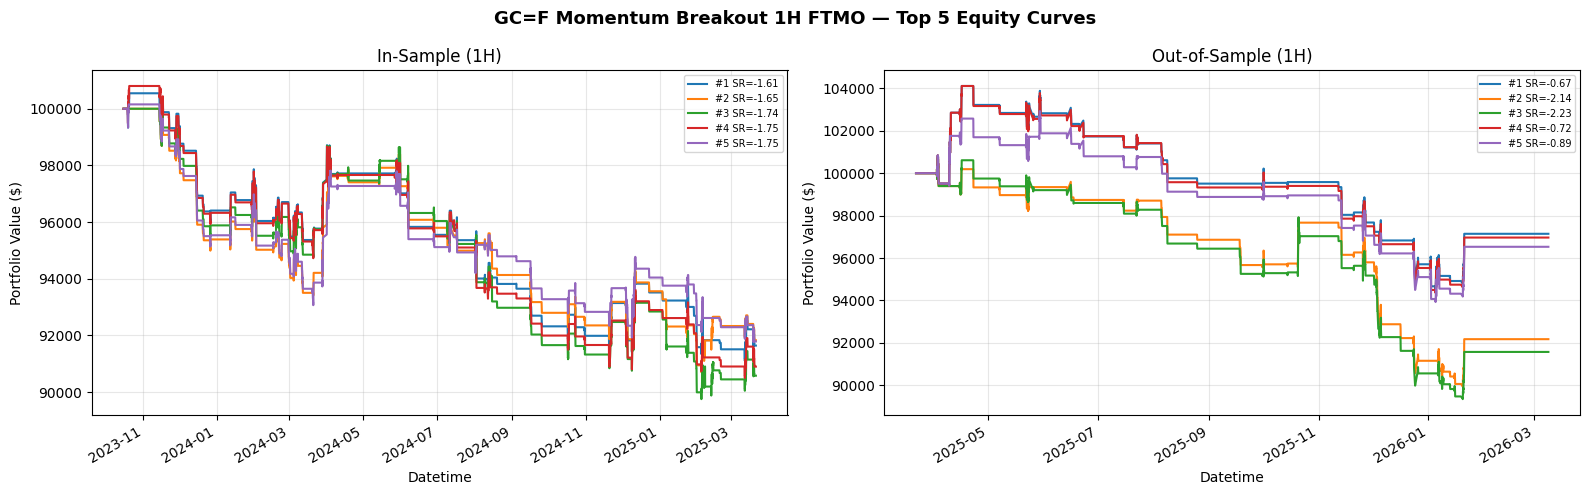

In [10]:
# ═══════════════════════════════════════════════════════════════
# Cell 10 — Top 5 OOS Validation (1H, freq='h')
# ═══════════════════════════════════════════════════════════════

top5 = results_df.head(5).copy()
val_high = high_series.iloc[split_idx:]
val_low  = low_series.iloc[split_idx:]

oos_results = []
is_portfolios = []
oos_portfolios = []

print(f"Validating top 5 IS combos on OOS data (1H)...\n")
print(f"{'Rank':<5} {'Params':<35} {'IS SR':>8} {'OOS SR':>8} {'IS Ret':>9} {'OOS Ret':>9} {'IS Tr':>6} {'OOS Tr':>7}")
print("-" * 90)

for rank, (_, row) in enumerate(top5.iterrows()):
    mp = int(row['mom_period']); tp = int(row['trend_period']); adx = int(row['adx_threshold'])
    sl_m = row['sl_atr_mult']; tp_m = row['tp_atr_mult']
    param_str = f"MOM({mp}) T={tp} ADX={adx} SL={sl_m} TP={tp_m}"

    # IS portfolio
    t_high = high_series.iloc[:split_idx]; t_low = low_series.iloc[:split_idx]
    ent_is, ext_is = generate_momentum_signals(train_close, t_high, t_low,
                                                mom_period=mp, trend_period=tp, adx_threshold=adx)
    sl_is, tp_is = compute_atr_stops(train_close, t_high, t_low, sl_mult=sl_m, tp_mult=tp_m)
    kw_is = dict(init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='h')
    if sl_is is not None: kw_is['sl_stop'] = sl_is
    if tp_is is not None: kw_is['tp_stop'] = tp_is
    pf_is = vbt.Portfolio.from_signals(close=train_close, entries=ent_is, exits=ext_is, **kw_is)
    is_portfolios.append(pf_is)

    # OOS portfolio
    ent_oos, ext_oos = generate_momentum_signals(val_close, val_high, val_low,
                                                  mom_period=mp, trend_period=tp, adx_threshold=adx)
    sl_oos, tp_oos = compute_atr_stops(val_close, val_high, val_low, sl_mult=sl_m, tp_mult=tp_m)
    kw_oos = dict(init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='h')
    if sl_oos is not None: kw_oos['sl_stop'] = sl_oos
    if tp_oos is not None: kw_oos['tp_stop'] = tp_oos
    pf_oos = vbt.Portfolio.from_signals(close=val_close, entries=ent_oos, exits=ext_oos, **kw_oos)
    oos_portfolios.append(pf_oos)

    def safe(fn, default=np.nan):
        try: return float(fn())
        except: return default

    is_sr = safe(lambda: pf_is.sharpe_ratio(freq='h'))
    oos_sr = safe(lambda: pf_oos.sharpe_ratio(freq='h'))
    is_ret = safe(pf_is.total_return); oos_ret = safe(pf_oos.total_return)
    is_trades = pf_is.trades.count(); oos_trades = pf_oos.trades.count()

    oos_results.append({
        'rank': rank+1, 'params': param_str,
        'mom_period': mp, 'trend_period': tp, 'adx_threshold': adx,
        'sl_atr_mult': sl_m, 'tp_atr_mult': tp_m,
        'is_sharpe': is_sr, 'oos_sharpe': oos_sr,
        'is_return': is_ret, 'oos_return': oos_ret,
        'is_trades': is_trades, 'oos_trades': oos_trades,
    })
    print(f"{rank+1:<5} {param_str:<35} {is_sr:>8.3f} {oos_sr:>8.3f} {is_ret:>9.2%} {oos_ret:>9.2%} {is_trades:>6} {oos_trades:>7}")

oos_df = pd.DataFrame(oos_results)
best_idx = oos_df['oos_sharpe'].idxmax()
BEST = oos_df.loc[best_idx]
print(f"\nBest OOS combo: MOM({int(BEST['mom_period'])}) Trend={int(BEST['trend_period'])} "
      f"ADX={int(BEST['adx_threshold'])} SL={BEST['sl_atr_mult']} TP={BEST['tp_atr_mult']}")

# Plot equity curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'{TICKER} Momentum Breakout 1H FTMO — Top 5 Equity Curves', fontsize=13, fontweight='bold')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i in range(len(is_portfolios)):
    r = oos_results[i]
    is_portfolios[i].value().plot(ax=axes[0], color=colors[i], linewidth=1.5, label=f"#{r['rank']} SR={r['is_sharpe']:.2f}")
    oos_portfolios[i].value().plot(ax=axes[1], color=colors[i], linewidth=1.5, label=f"#{r['rank']} SR={r['oos_sharpe']:.2f}")
for ax, t in zip(axes, ['In-Sample (1H)', 'Out-of-Sample (1H)']):
    ax.set_title(t); ax.set_ylabel('Portfolio Value ($)'); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Sensitivity Analysis

Sweep each parameter individually while holding others at best values. Flat bars = LOW sensitivity (robust). Large swings = HIGH sensitivity (fragile).

Color coding: dark green >+10%, light green 0-10%, orange -10-0%, red <-10%. Blue dashed vertical at base value.

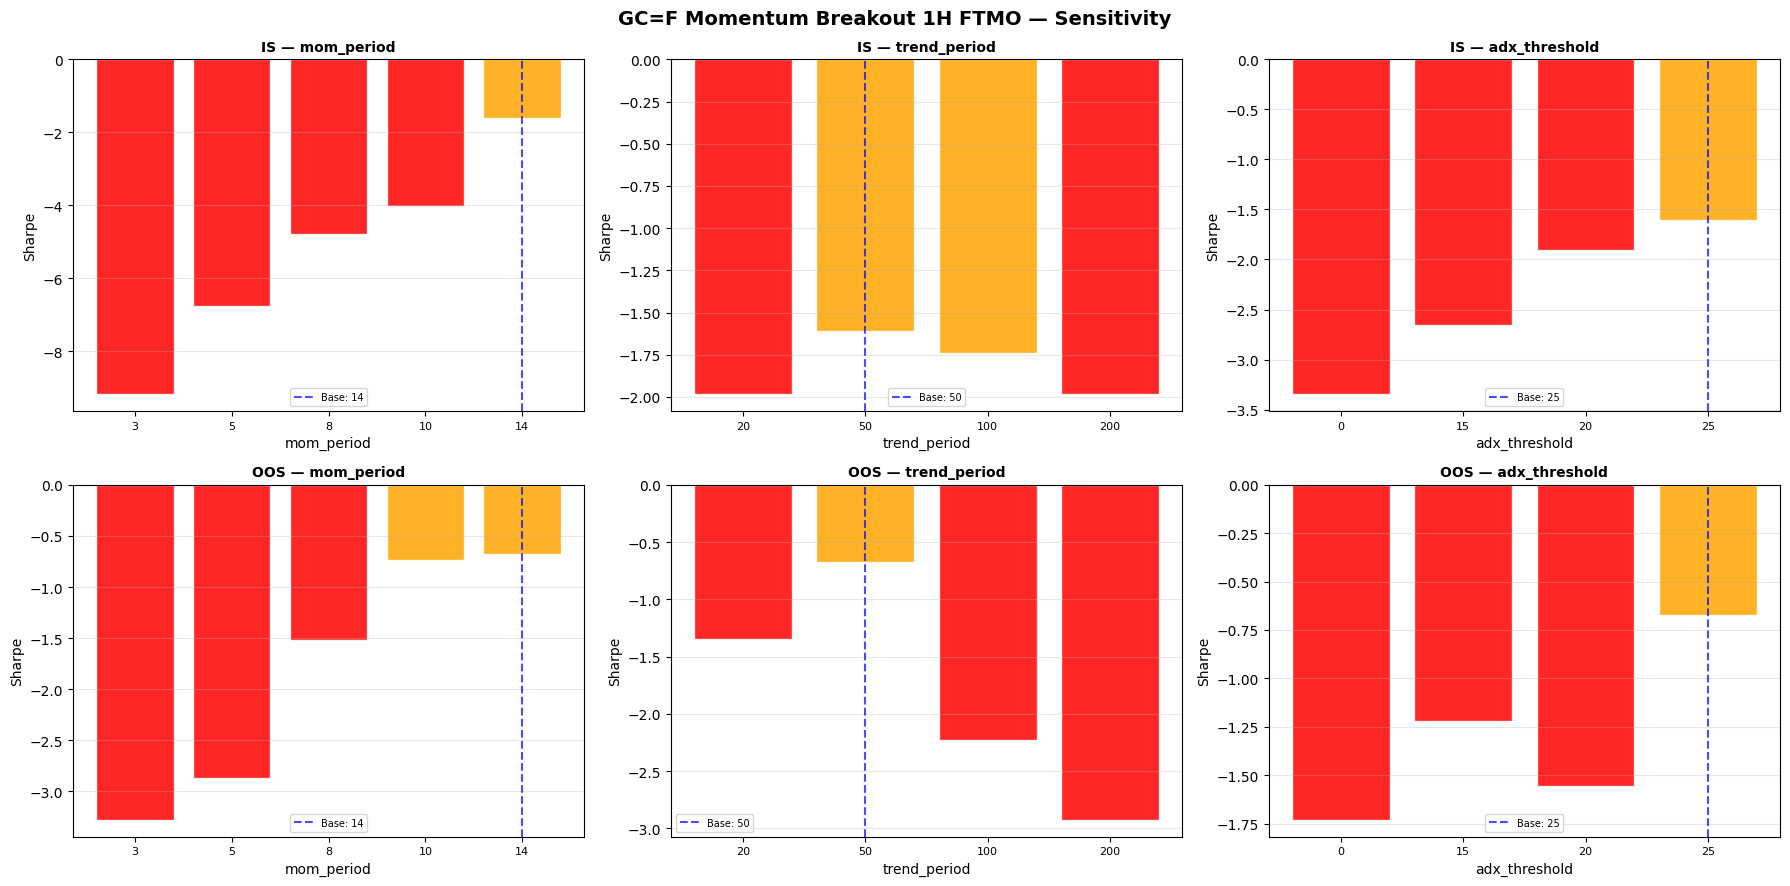


SENSITIVITY SUMMARY:
Parameter              IS Range  OOS Range  Sensitivity     Flag
-----------------------------------------------------------------
mom_period                7.572      2.605        1.436     HIGH
trend_period              0.376      2.253        0.726     HIGH
adx_threshold             1.739      1.058        0.761     HIGH


In [11]:
# ═══════════════════════════════════════════════════════════════
# Cell 12 — Sensitivity Analysis (1H, freq='h')
# ═══════════════════════════════════════════════════════════════

best_params = {
    'mom_period': int(BEST['mom_period']), 'trend_period': int(BEST['trend_period']),
    'adx_threshold': int(BEST['adx_threshold']),
    'sl_atr_mult': BEST['sl_atr_mult'], 'tp_atr_mult': BEST['tp_atr_mult'],
}

def run_sensitivity(close_s, high_s, low_s, param_name, param_values, base):
    sharpes = []
    for val in param_values:
        p = base.copy(); p[param_name] = val
        try:
            sig_p = {k: p[k] for k in ['mom_period', 'trend_period', 'adx_threshold']}
            ent, ext = generate_momentum_signals(close_s, high_s, low_s, **sig_p)
            sl_m = p['sl_atr_mult']; tp_m = p['tp_atr_mult']
            sl, tp = compute_atr_stops(close_s, high_s, low_s, sl_mult=sl_m, tp_mult=tp_m)
            kw = dict(init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='h')
            if sl is not None: kw['sl_stop'] = sl
            if tp is not None: kw['tp_stop'] = tp
            pf = vbt.Portfolio.from_signals(close=close_s, entries=ent, exits=ext, **kw)
            sr = float(pf.sharpe_ratio(freq='h'))
            sharpes.append(sr if not np.isnan(sr) else 0.0)
        except:
            sharpes.append(0.0)
    return sharpes

train_high = high_series.iloc[:split_idx]; train_low = low_series.iloc[:split_idx]

param_configs = [
    ('mom_period', mom_range, int(BEST['mom_period'])),
    ('trend_period', trend_range, int(BEST['trend_period'])),
    ('adx_threshold', adx_range, int(BEST['adx_threshold'])),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(f'{TICKER} Momentum Breakout 1H FTMO — Sensitivity', fontsize=14, fontweight='bold')
sensitivity_summary = []

for col, (pname, pvals, base_val) in enumerate(param_configs):
    is_sharpes = run_sensitivity(train_close, train_high, train_low, pname, pvals, best_params)
    oos_sharpes = run_sensitivity(val_close, val_high, val_low, pname, pvals, best_params)
    base_is = is_sharpes[pvals.index(base_val)] if base_val in pvals else np.mean(is_sharpes)
    base_oos = oos_sharpes[pvals.index(base_val)] if base_val in pvals else np.mean(oos_sharpes)

    for row_idx, (sharpes, prefix, base_sr) in enumerate([(is_sharpes, 'IS', base_is), (oos_sharpes, 'OOS', base_oos)]):
        ax = axes[row_idx][col]; x = np.arange(len(pvals))
        bar_colors = []
        for sr in sharpes:
            pct = (sr - base_sr) / abs(base_sr) * 100 if base_sr != 0 else 0
            if pct > 10: bar_colors.append('darkgreen')
            elif pct > 0: bar_colors.append('lightgreen')
            elif pct > -10: bar_colors.append('orange')
            else: bar_colors.append('red')
        ax.bar(x, sharpes, color=bar_colors, edgecolor='white', alpha=0.85)
        if base_val in pvals:
            ax.axvline(pvals.index(base_val), color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Base: {base_val}')
            ax.legend(fontsize=7)
        ax.set_xticks(x); ax.set_xticklabels([str(v) for v in pvals], fontsize=8)
        ax.set_xlabel(pname); ax.set_ylabel('Sharpe')
        ax.set_title(f'{prefix} — {pname}', fontsize=10, fontweight='bold'); ax.grid(alpha=0.3, axis='y')

    is_r = max(is_sharpes) - min(is_sharpes); oos_r = max(oos_sharpes) - min(oos_sharpes)
    avg = np.mean(is_sharpes + oos_sharpes)
    sens = (is_r + oos_r) / 2 / max(abs(avg), 0.01)
    sensitivity_summary.append((pname, is_r, oos_r, sens, "LOW" if sens < 0.5 else "HIGH"))

plt.tight_layout(); plt.show()
print(f"\nSENSITIVITY SUMMARY:")
print(f"{'Parameter':<20} {'IS Range':>10} {'OOS Range':>10} {'Sensitivity':>12} {'Flag':>8}")
print("-" * 65)
for p, ir, or_, s, f in sensitivity_summary:
    print(f"{p:<20} {ir:>10.3f} {or_:>10.3f} {s:>12.3f} {f:>8}")

Multi-Asset OOS — Momentum Breakout 1H FTMO best params
Params: MOM(14) Trend=50 ADX=25 SL=1.0 TP=4.0
Ticker        IS SR   OOS SR  IS Tr  OOS Tr   OOS Ret   OOS DD   OOS WR   OOS PF
--------------------------------------------------------------------------------------------------------------


GC=F         -1.608   -0.673    117      41    -2.86%   -9.21%    34.1%     0.79


CL=F         -2.866    0.459     53      47     3.39%  -10.61%    44.7%     1.17


SI=F         -2.904   -2.728     96      66   -21.43%  -22.22%    28.8%     0.40
QQQ          -2.098   -3.089     32      14    -4.45%   -6.09%    21.4%     0.34
SPY          -1.517   -1.580     31      15    -2.23%   -3.97%    33.3%     0.59


BTC-USD      -3.176   -3.800    104      63   -18.30%  -18.47%    17.5%     0.30


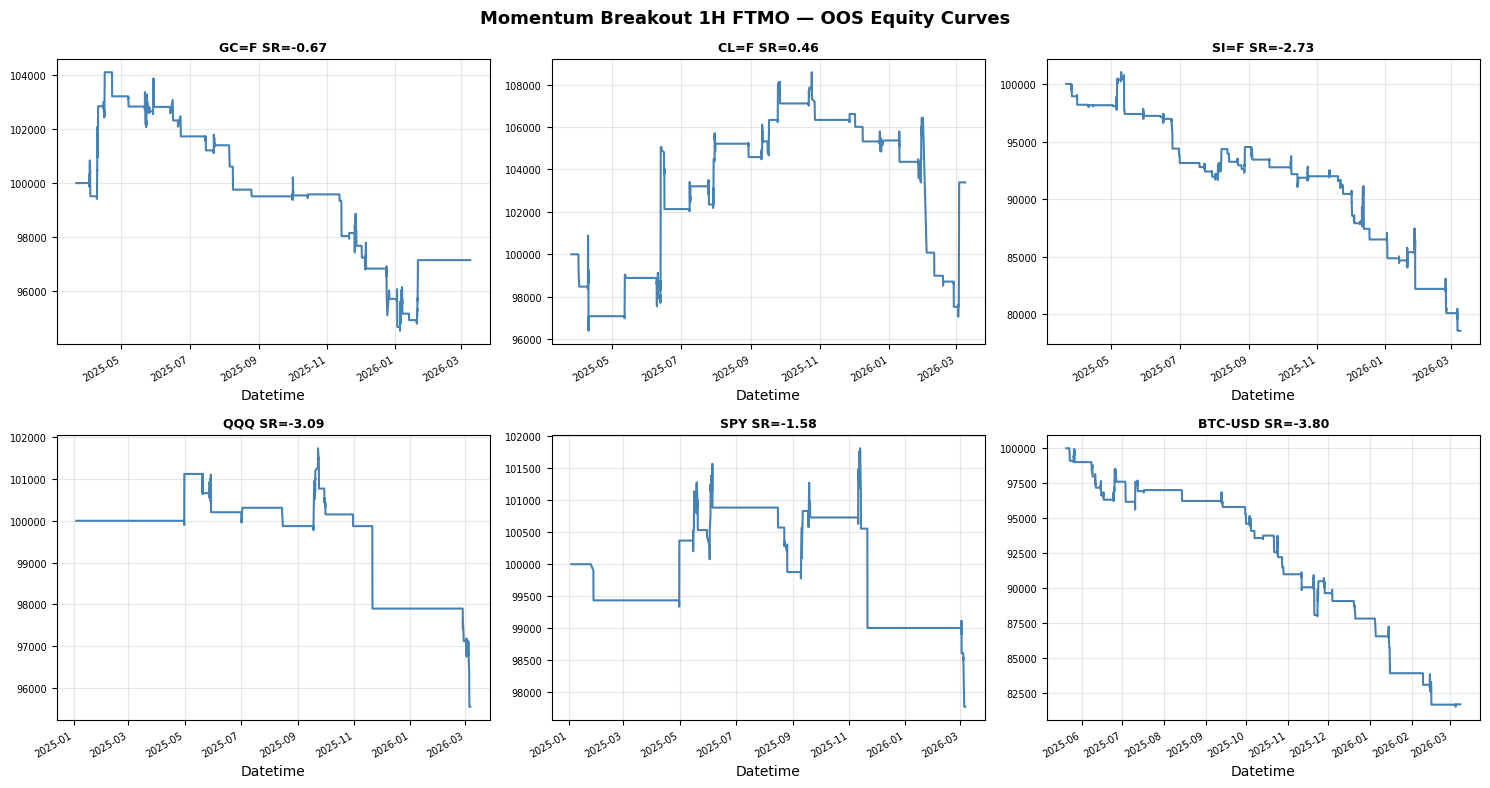

In [12]:
# ═══════════════════════════════════════════════════════════════
# Cell 13 — Multi-Asset OOS Validation (1H, freq='h')
# ═══════════════════════════════════════════════════════════════

sig_bp = {k: best_params[k] for k in ['mom_period', 'trend_period', 'adx_threshold']}

print(f"Multi-Asset OOS — Momentum Breakout 1H FTMO best params")
print(f"Params: MOM({sig_bp['mom_period']}) Trend={sig_bp['trend_period']} ADX={sig_bp['adx_threshold']} "
      f"SL={best_params['sl_atr_mult']} TP={best_params['tp_atr_mult']}")
print(f"{'='*110}")
print(f"{'Ticker':<10} {'IS SR':>8} {'OOS SR':>8} {'IS Tr':>6} {'OOS Tr':>7} {'OOS Ret':>9} {'OOS DD':>8} {'OOS WR':>8} {'OOS PF':>8}")
print(f"{'-'*110}")

multi_results = []
multi_portfolios = {}

for ticker in TICKERS:
    if ticker not in all_data:
        continue
    t_df = all_data[ticker]
    t_c = t_df['Close'].astype(float); t_c.name = 'price'
    t_h = t_df['High'].astype(float); t_l = t_df['Low'].astype(float)
    t_split = int(len(t_c) * TRAIN_RATIO)

    def safe(fn, default=np.nan):
        try: return float(fn())
        except: return default

    r = {'ticker': ticker}
    for label, slc in [('is', slice(0, t_split)), ('oos', slice(t_split, None))]:
        try:
            c, h, l = t_c.iloc[slc], t_h.iloc[slc], t_l.iloc[slc]
            ent, ext = generate_momentum_signals(c, h, l, **sig_bp)
            sl, tp = compute_atr_stops(c, h, l, sl_mult=best_params['sl_atr_mult'],
                                        tp_mult=best_params['tp_atr_mult'])
            kw = dict(init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='h')
            if sl is not None: kw['sl_stop'] = sl
            if tp is not None: kw['tp_stop'] = tp
            pf = vbt.Portfolio.from_signals(close=c, entries=ent, exits=ext, **kw)
            r[f'{label}_sharpe'] = safe(lambda: pf.sharpe_ratio(freq='h'))
            r[f'{label}_trades'] = pf.trades.count()
            if label == 'oos':
                r['oos_return'] = safe(pf.total_return)
                r['oos_maxdd'] = safe(pf.max_drawdown)
                tr = np.asarray(pf.trades.returns.values if hasattr(pf.trades.returns, 'values') else pf.trades.returns).ravel()
                pos = tr[tr > 0]; neg = tr[tr < 0]
                r['oos_wr'] = float(len(pos)/len(tr)*100) if len(tr) > 0 else np.nan
                r['oos_pf'] = float(pos.sum()/abs(neg.sum())) if len(neg) > 0 and abs(neg.sum()) > 0 else np.nan
            multi_portfolios[(ticker, label)] = pf
        except:
            r[f'{label}_sharpe'] = np.nan; r[f'{label}_trades'] = 0

    multi_results.append(r)
    fmt = lambda v, f: f.format(v) if not np.isnan(v) else "N/A"
    print(f"{ticker:<10} {fmt(r.get('is_sharpe',np.nan),'{:.3f}'):>8} {fmt(r.get('oos_sharpe',np.nan),'{:.3f}'):>8} "
          f"{r.get('is_trades',0):>6} {r.get('oos_trades',0):>7} "
          f"{fmt(r.get('oos_return',np.nan),'{:.2%}'):>9} {fmt(r.get('oos_maxdd',np.nan),'{:.2%}'):>8} "
          f"{fmt(r.get('oos_wr',np.nan),'{:.1f}%'):>8} {fmt(r.get('oos_pf',np.nan),'{:.2f}'):>8}")

# Plot OOS equity curves
cols = min(3, len(TICKERS)); rows = max((len(TICKERS) + cols - 1) // cols, 1)
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
fig.suptitle('Momentum Breakout 1H FTMO — OOS Equity Curves', fontsize=13, fontweight='bold')
if rows == 1 and cols > 1: axes = axes.reshape(1, -1)
elif rows == 1 and cols == 1: axes = np.array([[axes]])
axes_flat = axes.flatten()
for i, ticker in enumerate(TICKERS):
    ax = axes_flat[i]; pf = multi_portfolios.get((ticker, 'oos'))
    r = [x for x in multi_results if x['ticker'] == ticker]
    if pf and r:
        pf.value().plot(ax=ax, color='steelblue', linewidth=1.5)
        sr = r[0].get('oos_sharpe', np.nan)
        ax.set_title(f'{ticker} SR={sr:.2f}' if not np.isnan(sr) else ticker, fontsize=9, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No trades', ha='center', va='center'); ax.set_title(ticker, fontsize=9)
    ax.grid(alpha=0.3); ax.tick_params(labelsize=7)
for i in range(len(TICKERS), len(axes_flat)):
    axes_flat[i].set_visible(False)
plt.tight_layout(); plt.show()

Using default FTMO rules

OOS hourly returns: 5478 bars
Grouped into daily returns: 293 trading days
Daily return stats (unleveraged): mean=-0.0094%, std=0.3098%, min=-1.8208%, max=2.2812%
Daily return stats (leveraged 5.0x): mean=-0.0472%, std=1.5491%



FTMO Monte Carlo — 10,000 paths x 30 days (from 1H data)
Pass Rate                            9.4%
Fail (daily DD)                     40.8%
Fail (total DD)                      2.7%
Fail (time expired)                 47.1%
Mean Final P&L            $        -1,413
Median Final P&L          $        -1,497
P&L 5th percentile        $       -15,097
P&L 95th percentile       $        12,708
Verdict                          UNLIKELY


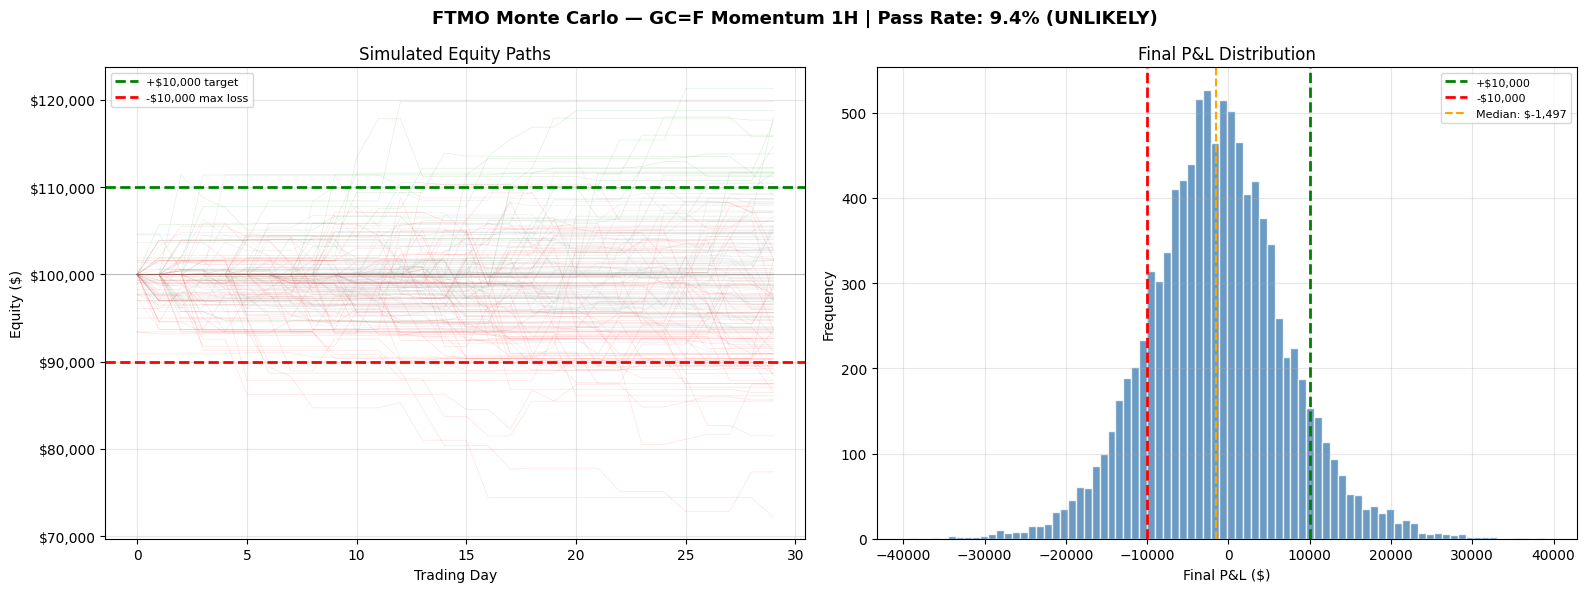

In [13]:
# ═══════════════════════════════════════════════════════════════
# Cell 14 — FTMO Monte Carlo (10,000 paths x 30 days, 1H -> daily)
# ═══════════════════════════════════════════════════════════════

import json

try:
    with open(os.path.join('config', 'ftmo_rules.json'), 'r') as f:
        ftmo_cfg = json.load(f)
    FTMO_ACCOUNT = ftmo_cfg['account_size']
    FTMO_PROFIT_TARGET = ftmo_cfg['profit_target_pct'] / 100
    FTMO_MAX_DAILY_DD = ftmo_cfg['max_daily_loss_pct'] / 100
    FTMO_MAX_TOTAL_DD = ftmo_cfg['max_total_loss_pct'] / 100
    FTMO_CHALLENGE_DAYS = ftmo_cfg['challenge_days']
    print("FTMO rules loaded from config/ftmo_rules.json")
except:
    FTMO_ACCOUNT = 100_000
    FTMO_PROFIT_TARGET = 0.10
    FTMO_MAX_DAILY_DD = 0.05
    FTMO_MAX_TOTAL_DD = 0.10
    FTMO_CHALLENGE_DAYS = 30
    print("Using default FTMO rules")

N_PATHS = 10_000

# Get 1H returns from best OOS portfolio
pf_best_oos = oos_portfolios[best_idx]
hourly_rets = pf_best_oos.returns().values.ravel()
hourly_rets = hourly_rets[~np.isnan(hourly_rets)]

# Group into daily returns (sum of hourly returns per calendar day)
oos_index = val_close.index
ret_series = pd.Series(hourly_rets[:len(oos_index)], index=oos_index)
daily_rets = ret_series.groupby(ret_series.index.date).sum().values

# Scale daily returns by FTMO leverage for realistic Monte Carlo
daily_rets_leveraged = daily_rets * FTMO_LEVERAGE

print(f"\nOOS hourly returns: {len(hourly_rets)} bars")
print(f"Grouped into daily returns: {len(daily_rets)} trading days")
print(f"Daily return stats (unleveraged): mean={daily_rets.mean():.4%}, std={daily_rets.std():.4%}, "
      f"min={daily_rets.min():.4%}, max={daily_rets.max():.4%}")
print(f"Daily return stats (leveraged {FTMO_LEVERAGE}x): mean={daily_rets_leveraged.mean():.4%}, "
      f"std={daily_rets_leveraged.std():.4%}")

if len(daily_rets) > 10:
    account = FTMO_ACCOUNT
    target = account * FTMO_PROFIT_TARGET
    max_daily = account * FTMO_MAX_DAILY_DD
    max_total = account * FTMO_MAX_TOTAL_DD
    n_days = FTMO_CHALLENGE_DAYS

    pass_count = fail_daily = fail_total = fail_time = 0
    final_pnls = []; sample_paths = []

    np.random.seed(42)
    for s in range(N_PATHS):
        sampled = np.random.choice(daily_rets_leveraged, size=n_days, replace=True)
        daily_pnl = account * sampled
        cum_pnl = np.cumsum(daily_pnl)
        equity = account + cum_pnl

        # Check FTMO rules
        if np.min(daily_pnl) <= -max_daily:
            fail_daily += 1
        elif np.max(np.maximum.accumulate(equity) - equity) >= max_total:
            fail_total += 1
        elif np.any(cum_pnl >= target):
            pass_count += 1
        else:
            fail_time += 1

        final_pnls.append(cum_pnl[-1])
        if s < 200:
            sample_paths.append(equity)

    pass_rate = pass_count / N_PATHS
    final_pnls = np.array(final_pnls)

    print(f"\n{'='*55}")
    print(f"FTMO Monte Carlo — {N_PATHS:,} paths x {n_days} days (from 1H data)")
    print(f"{'='*55}")
    print(f"{'Pass Rate':<25} {pass_rate:>15.1%}")
    print(f"{'Fail (daily DD)':<25} {fail_daily/N_PATHS:>15.1%}")
    print(f"{'Fail (total DD)':<25} {fail_total/N_PATHS:>15.1%}")
    print(f"{'Fail (time expired)':<25} {fail_time/N_PATHS:>15.1%}")
    print(f"{'Mean Final P&L':<25} ${final_pnls.mean():>14,.0f}")
    print(f"{'Median Final P&L':<25} ${np.median(final_pnls):>14,.0f}")
    print(f"{'P&L 5th percentile':<25} ${np.percentile(final_pnls, 5):>14,.0f}")
    print(f"{'P&L 95th percentile':<25} ${np.percentile(final_pnls, 95):>14,.0f}")

    verdict = ("FAVORABLE" if pass_rate >= 0.50 else "POSSIBLE" if pass_rate >= 0.25
               else "CHALLENGING" if pass_rate >= 0.10 else "UNLIKELY")
    print(f"{'Verdict':<25} {verdict:>15}")

    # Plot: 2 subplots — equity paths and final P&L histogram
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'FTMO Monte Carlo — {TICKER} Momentum 1H | Pass Rate: {pass_rate:.1%} ({verdict})',
                 fontsize=13, fontweight='bold')

    # Equity paths
    for path in sample_paths:
        final = path[-1]
        if final >= account + target:
            c = 'green'
        elif np.max(np.maximum.accumulate(path) - path) >= max_total or np.min(np.diff(np.concatenate([[account], path]))) <= -max_daily:
            c = 'red'
        else:
            c = 'gray'
        axes[0].plot(range(n_days), path, color=c, alpha=0.12, linewidth=0.5)

    axes[0].axhline(account + target, color='green', linestyle='--', linewidth=2,
                     label=f'+${target:,.0f} target')
    axes[0].axhline(account - max_total, color='red', linestyle='--', linewidth=2,
                     label=f'-${max_total:,.0f} max loss')
    axes[0].axhline(account, color='gray', linestyle='-', linewidth=0.8, alpha=0.4)
    axes[0].set_xlabel('Trading Day'); axes[0].set_ylabel('Equity ($)')
    axes[0].set_title('Simulated Equity Paths'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    # Final P&L histogram
    axes[1].hist(final_pnls, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1].axvline(target, color='green', linestyle='--', linewidth=2, label=f'+${target:,.0f}')
    axes[1].axvline(-max_total, color='red', linestyle='--', linewidth=2, label=f'-${max_total:,.0f}')
    axes[1].axvline(np.median(final_pnls), color='orange', linestyle='--', linewidth=1.5,
                     label=f'Median: ${np.median(final_pnls):,.0f}')
    axes[1].set_xlabel('Final P&L ($)'); axes[1].set_ylabel('Frequency')
    axes[1].set_title('Final P&L Distribution'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()
else:
    print("Not enough OOS data for Monte Carlo simulation")

In [14]:
# ═══════════════════════════════════════════════════════════════
# Cell 15 — Universal Export
# ═══════════════════════════════════════════════════════════════

import os, sys, json, datetime, shutil

STRATEGY_NAME = "Momentum_Breakout_FTMO_1H"
PARAM_COLS = ["mom_period", "trend_period", "adx_threshold", "sl_atr_mult", "tp_atr_mult"]

EXPORT_DIR = "./strategy_exports"
try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    EXPORT_DIR = "/content/drive/MyDrive/strategy_exports"
except:
    pass

RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
STRAT_DIR = os.path.join(EXPORT_DIR, STRATEGY_NAME, TICKER)
LATEST_DIR = os.path.join(STRAT_DIR, "latest")
ARCHIVE_DIR = os.path.join(STRAT_DIR, "archive")
os.makedirs(LATEST_DIR, exist_ok=True); os.makedirs(ARCHIVE_DIR, exist_ok=True)

# Build metrics for best OOS combo
pf_best_is = is_portfolios[best_idx]
pf_best_oos = oos_portfolios[best_idx]

def safe(fn, default=np.nan):
    try: return float(fn())
    except: return default

# Full-sample portfolio for export metrics
full_high = high_series; full_low = low_series
ent_full, ext_full = generate_momentum_signals(close_series, full_high, full_low,
                                                mom_period=best_params['mom_period'],
                                                trend_period=best_params['trend_period'],
                                                adx_threshold=best_params['adx_threshold'])
sl_full, tp_full = compute_atr_stops(close_series, full_high, full_low,
                                      sl_mult=best_params['sl_atr_mult'],
                                      tp_mult=best_params['tp_atr_mult'])
kw_full = dict(init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='h')
if sl_full is not None: kw_full['sl_stop'] = sl_full
if tp_full is not None: kw_full['tp_stop'] = tp_full
pf_full = vbt.Portfolio.from_signals(close=close_series, entries=ent_full, exits=ext_full, **kw_full)

# Extract trade returns
trades_obj = pf_full.trades
tr = np.asarray(trades_obj.returns.values if hasattr(trades_obj.returns, 'values') else trades_obj.returns).ravel()
pnl = np.asarray(trades_obj.pnl.values if hasattr(trades_obj.pnl, 'values') else trades_obj.pnl).ravel()
pos = tr[tr > 0]; neg = tr[tr < 0]
hours_total = len(close_series)
years_full = max(hours_total / (252 * 7), 0.01)

export_json = {
    "metadata": {
        "run_id": RUN_ID,
        "strategy_name": STRATEGY_NAME,
        "ticker": TICKER,
        "data_interval": "1h",
        "frequency": "h",
        "start_date": str(close_series.index[0]),
        "end_date": str(close_series.index[-1]),
        "total_bars": len(close_series),
        "total_years": round(years_full, 2),
        "train_ratio": TRAIN_RATIO,
        "init_cash": INIT_CASH,
        "fees_pct": FEES,
        "slippage_pct": SLIPPAGE,
        "ftmo_leverage": FTMO_LEVERAGE,
        "risk_per_trade": RISK_PER_TRADE,
        "grid_combos_tested": len(results_df),
    },
    "best_params": best_params,
    "metrics_full_sample": {
        "sharpe": safe(lambda: pf_full.sharpe_ratio(freq='h')),
        "sortino": safe(lambda: pf_full.sortino_ratio(freq='h')),
        "total_return": safe(pf_full.total_return),
        "ann_return": safe(lambda: pf_full.annualized_return(freq='h')),
        "max_dd": safe(pf_full.max_drawdown),
        "volatility": safe(lambda: pf_full.annualized_volatility(freq='h')),
        "trades": int(trades_obj.count()),
        "trades_per_year": trades_obj.count() / years_full,
        "win_rate": float(len(pos)/len(tr)*100) if len(tr) > 0 else None,
        "profit_factor": float(pos.sum()/abs(neg.sum())) if len(neg) > 0 and abs(neg.sum()) > 0 else None,
        "expectancy": float(tr.mean()) if len(tr) > 0 else None,
        "avg_win": float(pos.mean()) if len(pos) > 0 else None,
        "avg_loss": float(neg.mean()) if len(neg) > 0 else None,
        "payoff_ratio": float(abs(pos.mean()/neg.mean())) if len(pos) > 0 and len(neg) > 0 else None,
    },
    "metrics_in_sample": {
        "sharpe": safe(lambda: pf_best_is.sharpe_ratio(freq='h')),
        "return": safe(pf_best_is.total_return),
        "max_dd": safe(pf_best_is.max_drawdown),
        "trades": int(pf_best_is.trades.count()),
    },
    "metrics_out_of_sample": {
        "sharpe": safe(lambda: pf_best_oos.sharpe_ratio(freq='h')),
        "return": safe(pf_best_oos.total_return),
        "max_dd": safe(pf_best_oos.max_drawdown),
        "trades": int(pf_best_oos.trades.count()),
    },
    "oos_validation_top5": oos_results,
    "multi_asset_results": multi_results,
}

# Add Monte Carlo results if available
try:
    export_json["monte_carlo_ftmo"] = {
        "n_paths": N_PATHS,
        "challenge_days": FTMO_CHALLENGE_DAYS,
        "pass_rate": float(pass_rate),
        "fail_daily_pct": float(fail_daily / N_PATHS),
        "fail_total_pct": float(fail_total / N_PATHS),
        "fail_time_pct": float(fail_time / N_PATHS),
        "mean_final_pnl": float(final_pnls.mean()),
        "median_final_pnl": float(np.median(final_pnls)),
        "verdict": verdict,
        "data_source": "1H OOS returns grouped to daily, scaled by FTMO_LEVERAGE",
    }
except:
    pass

# Save JSON
json_path = os.path.join(LATEST_DIR, "summary.json")
with open(json_path, 'w') as f:
    json.dump(export_json, f, indent=2, default=str)
print(f"summary.json saved")

# Save grid results CSV
results_df.to_csv(os.path.join(LATEST_DIR, "grid_results.csv"), index=False)
print(f"grid_results.csv saved ({len(results_df)} rows)")

# Save trades CSV
if len(tr) > 0:
    pd.DataFrame({
        'trade_num': range(1, len(tr)+1),
        'return_pct': tr * 100,
        'pnl_usd': pnl,
        'cumulative_pnl': np.cumsum(pnl),
        'is_winner': tr > 0,
    }).to_csv(os.path.join(LATEST_DIR, "trades.csv"), index=False)
    print(f"trades.csv saved ({len(tr)} trades)")

# Save hourly returns CSV
hourly_returns = pf_full.returns()
pd.DataFrame({
    'datetime': close_series.index,
    'strategy_return': hourly_returns.values,
    'close': close_series.values,
    'portfolio_value': pf_full.value().values,
}).to_csv(os.path.join(LATEST_DIR, "hourly_returns.csv"), index=False)
print(f"hourly_returns.csv saved")

# Archive
shutil.copy2(json_path, os.path.join(ARCHIVE_DIR, f"{RUN_ID}_summary.json"))

# Run log
log_path = os.path.join(EXPORT_DIR, "run_log.csv")
log_entry = pd.DataFrame([{
    "run_id": RUN_ID,
    "timestamp": datetime.datetime.now().isoformat(),
    "strategy": STRATEGY_NAME,
    "ticker": TICKER,
    "interval": "1h",
    "best_params": str(best_params),
    "sharpe_full": round(export_json['metrics_full_sample']['sharpe'] or 0, 4),
    "sharpe_is": round(export_json['metrics_in_sample']['sharpe'] or 0, 4),
    "sharpe_oos": round(export_json['metrics_out_of_sample']['sharpe'] or 0, 4),
    "total_return": round(export_json['metrics_full_sample']['total_return'] or 0, 4),
    "max_drawdown": round(export_json['metrics_full_sample']['max_dd'] or 0, 4),
    "total_trades": export_json['metrics_full_sample']['trades'],
    "ftmo_pass_rate": round(export_json.get('monte_carlo_ftmo', {}).get('pass_rate', 0), 3),
    "ftmo_verdict": export_json.get('monte_carlo_ftmo', {}).get('verdict', 'N/A'),
    "export_path": STRAT_DIR,
}])
if os.path.exists(log_path):
    log_combined = pd.concat([pd.read_csv(log_path), log_entry], ignore_index=True)
else:
    log_combined = log_entry
log_combined.to_csv(log_path, index=False)

print(f"\nExport complete: {STRATEGY_NAME} / {TICKER}")
print(f"  Run ID: {RUN_ID}")
print(f"  Best params: {best_params}")
print(f"  Saved to: {LATEST_DIR}")
print(f"  Run log: {log_path} ({len(log_combined)} total runs)")

summary.json saved
grid_results.csv saved (720 rows)
trades.csv saved (158 trades)
hourly_returns.csv saved

Export complete: Momentum_Breakout_FTMO_1H / GC=F
  Run ID: 20260308_191200
  Best params: {'mom_period': 14, 'trend_period': 50, 'adx_threshold': 25, 'sl_atr_mult': np.float64(1.0), 'tp_atr_mult': np.float64(4.0)}
  Saved to: ./strategy_exports\Momentum_Breakout_FTMO_1H\GC=F\latest
  Run log: ./strategy_exports\run_log.csv (1 total runs)
